# Laboratorio 4 — Inciso 3: Índices de cianobacteria, NDVI y NDWI

El cálculo de los tres índices ya ocurre en la Process API al momento de la descarga (inciso 2), mediante el evalscript propio `src/evalscripts.py` que porta la matemática del script oficial *CyanoLakes Chlorophyll-a NDCI L1C*. Este notebook se limita a cargar un raster ya descargado por lago, aplicar la máscara de agua y visualizar el índice de cianobacteria (`clorofila`), el NDVI y el NDWI en un mapa por lago.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt

from src.config import FECHAS_OFICIALES, LAGOS, RUTA_FIGURAS
from src.descarga import descargar_fecha
from src.raster import abrir, recorte_percentil

## Carga de un raster por lago

Se usa la primera fecha oficial de cada lago. `descargar_fecha` es idempotente: si el archivo ya existe en `data/raw/`, no vuelve a pedirlo a la Process API.

In [2]:
from src.conexion import crear_config

config = crear_config()

rasters = {}
for lago in LAGOS:
    fecha = FECHAS_OFICIALES[lago][0]
    ruta = descargar_fecha(config, lago, fecha)
    rasters[lago] = {"fecha": fecha, "bandas": abrir(ruta)}

{lago: info["fecha"] for lago, info in rasters.items()}

{'atitlan': '2025-01-18', 'amatitlan': '2025-01-28'}

## Mapas de índices por lago

Para cada lago se grafican `clorofila` (índice de cianobacteria), `ndvi` y `ndwi`, aplicando la máscara de agua (`agua > 0`) antes de graficar. La escala de color de cada índice se recorta al percentil 2–98 dentro de la máscara de agua, en lugar de usar el mínimo/máximo absoluto, porque `clorofila` presenta valores extremos en píxeles mixtos de borde donde el denominador del NDCI (`B05+B04`) es cercano a cero.

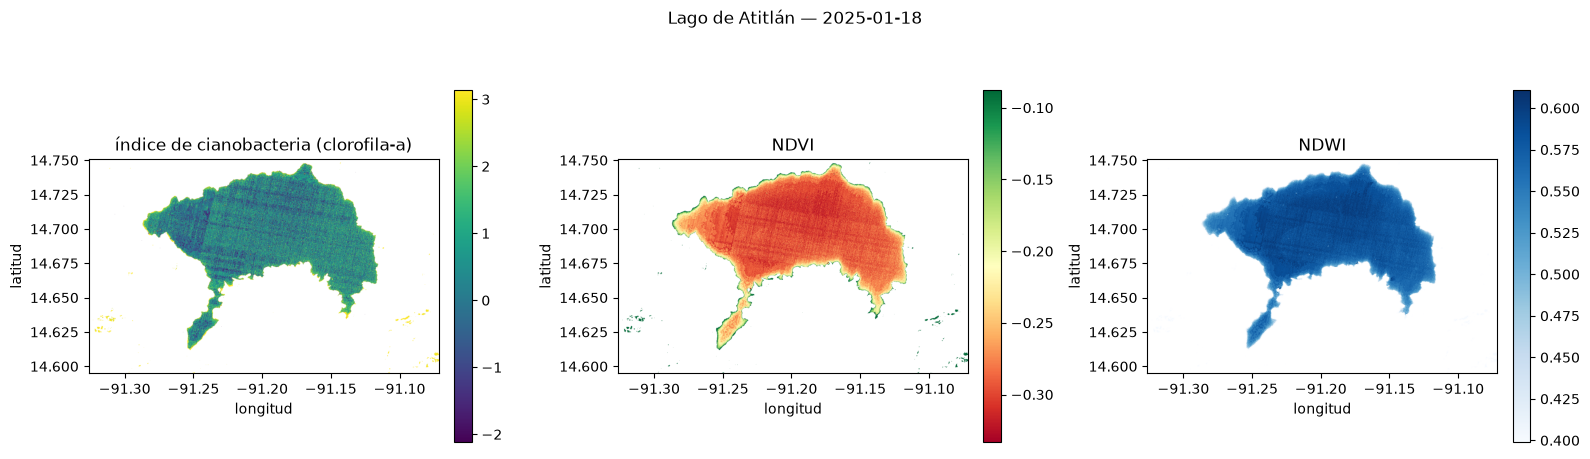

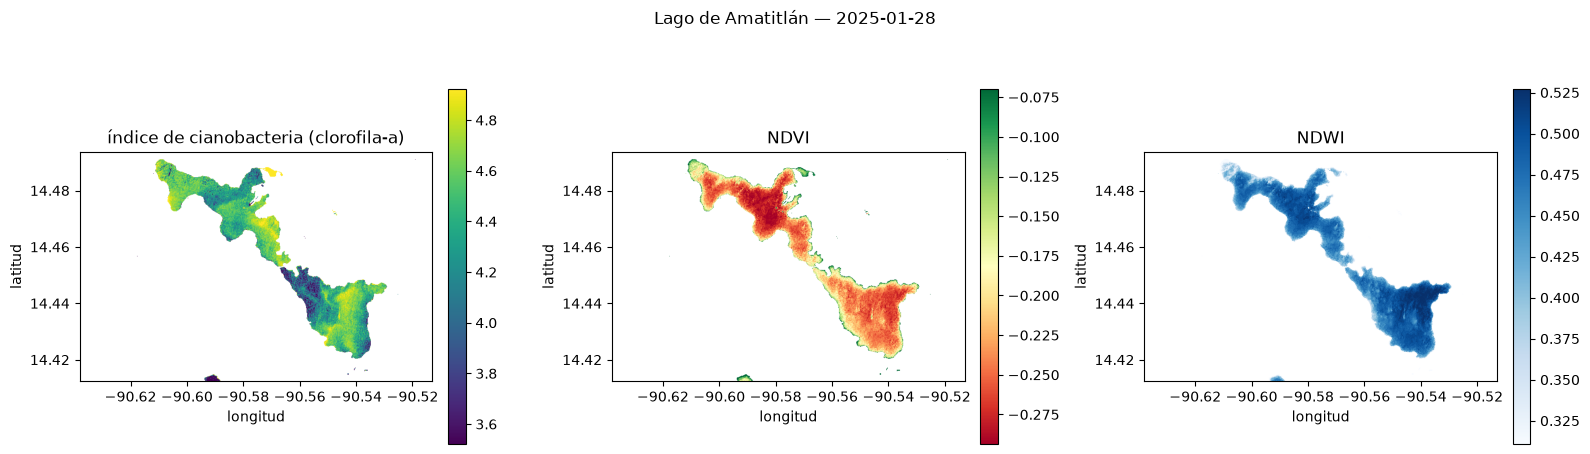

In [3]:
indices = [
    ("clorofila", "índice de cianobacteria (clorofila-a)", "viridis"),
    ("ndvi", "NDVI", "RdYlGn"),
    ("ndwi", "NDWI", "Blues"),
]

for lago, info in rasters.items():
    bandas = info["bandas"]
    agua = bandas["agua"]
    west, south, east, north = LAGOS[lago]["bbox"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (nombre_banda, titulo, cmap) in zip(axes, indices):
        enmascarada, vmin, vmax = recorte_percentil(bandas[nombre_banda], agua)
        im = ax.imshow(enmascarada, cmap=cmap, vmin=vmin, vmax=vmax, extent=(west, east, south, north))
        ax.set_title(titulo)
        ax.set_xlabel("longitud")
        ax.set_ylabel("latitud")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"{LAGOS[lago]['nombre']} — {info['fecha']}")
    fig.tight_layout()
    fig.savefig(RUTA_FIGURAS / f"indices_{lago}.png", dpi=150, bbox_inches="tight")
    plt.show()

La interpretación de estos mapas se documenta en `informe/secciones/03_indices_cianobacteria.md`.